In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

 final_simplex: (array([[7.87494894, 0.00887503],
       [7.875     , 0.008875  ],
       [7.87499658, 0.00887499]]), array([0.00038955, 0.00039045, 0.0004492 ]))
           fun: 0.00038955027716213093
       message: 'Optimization terminated successfully.'
          nfev: 69
           nit: 28
        status: 0
       success: True
             x: array([7.87494894, 0.00887503])
 final_simplex: (array([[1.08521146, 3.29346786],
       [1.08524346, 3.29348403],
       [1.0851397 , 3.29350611]]), array([4.40719571e-05, 4.40719578e-05, 4.40719602e-05]))
           fun: 4.407195705766845e-05
       message: 'Optimization terminated successfully.'
          nfev: 80
           nit: 41
        status: 0
       success: True
             x: array([1.08521146, 3.29346786])


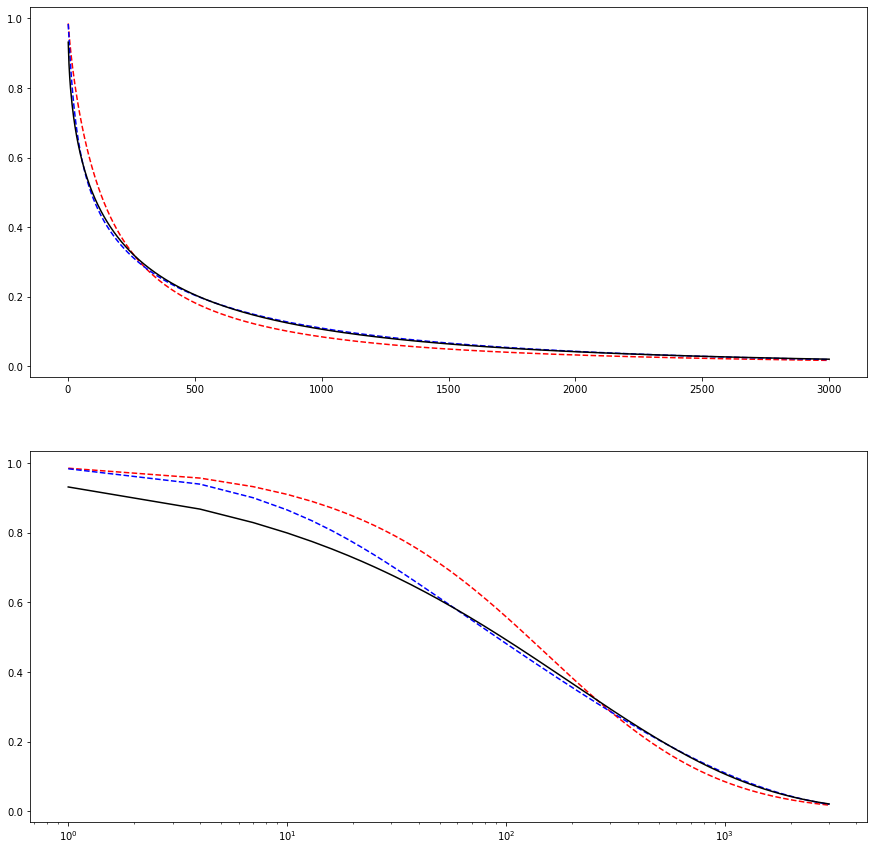

In [600]:
times = np.linspace(1,3000,1000)
stretched_exponential_factor = 200
stretched_exponential = np.exp(-(times/stretched_exponential_factor)**0.5)

def sum_linspace_factor_factorial(linspace_bound, times):
    min_factor, max_factor = linspace_bound
    factors = np.linspace(min_factor, max_factor, 100)
    return np.exp(-np.array([times]).T/factors).mean(axis=1) 

def sum_logspace_factor_exp(logspace_bound, times):
    min_factor, max_factor = logspace_bound
    factors = np.logspace(min_factor, max_factor, 100)
    return np.exp(-np.array([times]).T/factors).mean(axis=1)

def get_distance(x_i, x_j):
   return ((x_i - x_j)**2).sum()**0.5

def sum_dipolar_factor_exponential(dipolar_parameters, times):
    Gaussian_stdev, dipolar_intensity = dipolar_parameters  
    n_NVC = 500
    x = np.random.normal(scale=Gaussian_stdev, size=(n_NVC,3))
    factors = [1/np.sum([0 if get_distance(x_i, x_j)==0 else dipolar_intensity/get_distance(x_i, x_j)**3 for x_j in x]) for x_i in x]
    return np.exp(-np.array([times]).T/factors).mean(axis=1)

def mse(x, curve_fn, times, stretched_exp):
    curve = curve_fn(x, times)
    return ((curve - stretched_exp)**2).mean(axis=0)


dipolar_parameters = (7.5, 0.01)
dipolar_optimal_result = minimize(mse, dipolar_parameters, args=(sum_dipolar_factor_exponential, times, stretched_exponential), method='Nelder-Mead')
dipolar_ensemble_exponential = sum_dipolar_factor_exponential(dipolar_optimal_result.x, times)

logspace_bound = (1, 4)
logspace_mse_result = minimize(mse, logspace_bound, args=(sum_logspace_factor_exp, times, stretched_exponential), method='Nelder-Mead')
logspace_ensemble_exponential = sum_logspace_factor_exp(logspace_mse_result.x, times)


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15,15))
ax[0].plot(times, dipolar_ensemble_exponential, '--', c=(1,0,0))
ax[0].plot(times, logspace_ensemble_exponential, '--', c=(0,0,1))
ax[0].plot(times, stretched_exponential, '-', c=(0,0,0))
ax[0].set_xscale('linear')
ax[1].plot(times, dipolar_ensemble_exponential, '--', c=(1,0,0))
ax[1].plot(times, logspace_ensemble_exponential, '--', c=(0,0,1))
ax[1].plot(times, stretched_exponential, '-', c=(0,0,0))
ax[1].set_xscale('log')
plt.show()